<a href="https://colab.research.google.com/github/parveen180/Machine-learning-project-python/blob/main/Autism_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [126]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split,cross_val_score,RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import pickle
from sklearn.utils import resample

In [127]:
dataset=pd.read_csv('/content/train (1).csv')

In [128]:
pd.set_option('display.max_columns',None)

In [129]:
dataset.tail()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
795,796,0,1,0,0,0,0,0,0,1,1,16.597187,m,Hispanic,no,no,New Zealand,no,12.999501,18 and more,Self,0
796,797,0,1,1,0,0,1,0,1,1,1,20.703001,m,White-European,no,no,Cyprus,no,13.561518,18 and more,Self,0
797,798,0,0,0,0,0,0,0,0,0,0,5.711481,m,South Asian,yes,no,New Zealand,no,2.653177,18 and more,Self,0
798,799,0,0,0,0,0,0,0,0,0,0,16.414305,f,?,no,no,Canada,no,9.069342,18 and more,Self,0
799,800,0,1,0,0,0,0,0,0,0,0,46.966113,f,?,no,no,United Arab Emirates,yes,2.243304,18 and more,Self,0


In [130]:
list(dataset.columns)

['ID',
 'A1_Score',
 'A2_Score',
 'A3_Score',
 'A4_Score',
 'A5_Score',
 'A6_Score',
 'A7_Score',
 'A8_Score',
 'A9_Score',
 'A10_Score',
 'age',
 'gender',
 'ethnicity',
 'jaundice',
 'austim',
 'contry_of_res',
 'used_app_before',
 'result',
 'age_desc',
 'relation',
 'Class/ASD']

In [131]:
#converting ag column to int
dataset['age']=dataset['age'].astype(int)

In [132]:
#find unique values
for columns in dataset.columns:
    numerical_features=["ID","age","result"]
    if columns not in numerical_features:
        print(columns,dataset[columns].unique())
        print("-"*90)

A1_Score [1 0]
------------------------------------------------------------------------------------------
A2_Score [0 1]
------------------------------------------------------------------------------------------
A3_Score [1 0]
------------------------------------------------------------------------------------------
A4_Score [0 1]
------------------------------------------------------------------------------------------
A5_Score [1 0]
------------------------------------------------------------------------------------------
A6_Score [0 1]
------------------------------------------------------------------------------------------
A7_Score [1 0]
------------------------------------------------------------------------------------------
A8_Score [0 1]
------------------------------------------------------------------------------------------
A9_Score [1 0]
------------------------------------------------------------------------------------------
A10_Score [1 0]
------------------------------

In [133]:
dataset.drop(columns=['ID','age_desc'],inplace=True)

In [134]:
dataset.shape

(800, 20)

In [135]:
dataset.head(2)

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,relation,Class/ASD
0,1,0,1,0,1,0,1,0,1,1,38,f,?,no,no,Austria,no,6.351166,Self,0
1,0,0,0,0,0,0,0,0,0,0,47,m,?,no,no,India,no,2.255185,Self,0


In [136]:
dataset['contry_of_res'].unique()

array(['Austria', 'India', 'United States', 'South Africa', 'Jordan',
       'United Kingdom', 'Brazil', 'New Zealand', 'Canada', 'Kazakhstan',
       'United Arab Emirates', 'Australia', 'Ukraine', 'Iraq', 'France',
       'Malaysia', 'Viet Nam', 'Egypt', 'Netherlands', 'Afghanistan',
       'Oman', 'Italy', 'AmericanSamoa', 'Bahamas', 'Saudi Arabia',
       'Ireland', 'Aruba', 'Sri Lanka', 'Russia', 'Bolivia', 'Azerbaijan',
       'Armenia', 'Serbia', 'Ethiopia', 'Sweden', 'Iceland', 'Hong Kong',
       'Angola', 'China', 'Germany', 'Spain', 'Tonga', 'Pakistan', 'Iran',
       'Argentina', 'Japan', 'Mexico', 'Nicaragua', 'Sierra Leone',
       'Czech Republic', 'Niger', 'Romania', 'Cyprus', 'Belgium',
       'Burundi', 'Bangladesh'], dtype=object)

In [137]:
mapping={
    "Viet Nam":"Vietnam",
    "AmericanSamoa":"United States",
    "Hong Kong":"China"


}

dataset['contry_of_res']=dataset['contry_of_res'].replace(mapping)

In [138]:
dataset['contry_of_res'].unique()

array(['Austria', 'India', 'United States', 'South Africa', 'Jordan',
       'United Kingdom', 'Brazil', 'New Zealand', 'Canada', 'Kazakhstan',
       'United Arab Emirates', 'Australia', 'Ukraine', 'Iraq', 'France',
       'Malaysia', 'Vietnam', 'Egypt', 'Netherlands', 'Afghanistan',
       'Oman', 'Italy', 'Bahamas', 'Saudi Arabia', 'Ireland', 'Aruba',
       'Sri Lanka', 'Russia', 'Bolivia', 'Azerbaijan', 'Armenia',
       'Serbia', 'Ethiopia', 'Sweden', 'Iceland', 'China', 'Angola',
       'Germany', 'Spain', 'Tonga', 'Pakistan', 'Iran', 'Argentina',
       'Japan', 'Mexico', 'Nicaragua', 'Sierra Leone', 'Czech Republic',
       'Niger', 'Romania', 'Cyprus', 'Belgium', 'Burundi', 'Bangladesh'],
      dtype=object)

**Exploritory Data Analysis (EDA)**

In [139]:
dataset.columns

Index(['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender',
       'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before',
       'result', 'relation', 'Class/ASD'],
      dtype='object')

In [140]:
sns.set_theme(style="darkgrid")

NUMERICAL DATA

AGE

RESULT

Mean: 27.96375
Median: 24.0


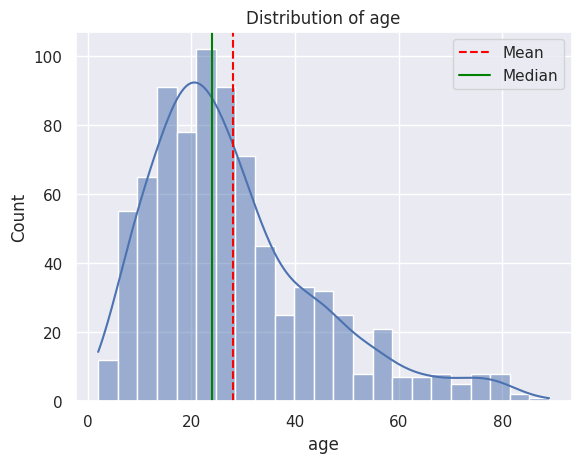

In [141]:
sns.histplot(dataset['age'], kde=True)
plt.title(f"Distribution of age")
age_mean=dataset['age'].mean()
age_median=dataset['age'].median()
print(f"Mean: {age_mean}")
print(f"Median: {age_median}")
plt.axvline(age_mean, color='red', linestyle='--', label='Mean')
plt.axvline(age_median, color='green', linestyle='-', label='Median')
plt.legend()
plt.show()

Mean: 8.537303106501248
Median: 9.605299308


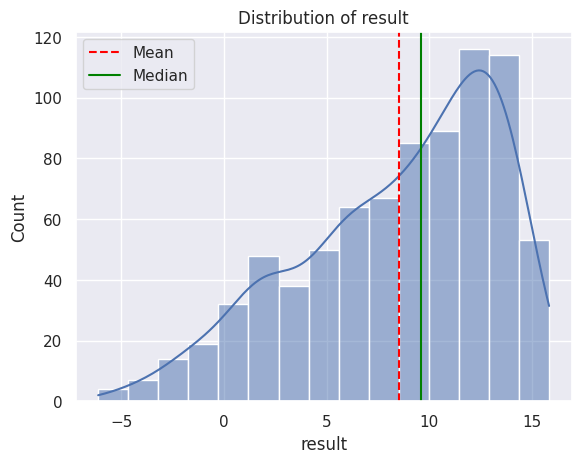

In [142]:
sns.histplot(dataset['result'], kde=True)
plt.title(f"Distribution of result")
result_mean=dataset['result'].mean()
result_median=dataset['result'].median()
print(f"Mean: {result_mean}")
print(f"Median: {result_median}")
plt.axvline(result_mean, color='red', linestyle='--', label='Mean')
plt.axvline(result_median, color='green', linestyle='-', label='Median')
plt.legend()
plt.show()

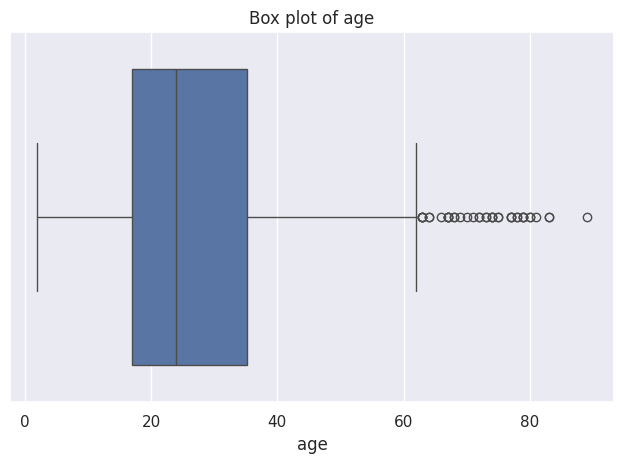

In [143]:
sns.boxplot(x=dataset['age'])
plt.title("Box plot of age")
plt.tight_layout()
plt.show()

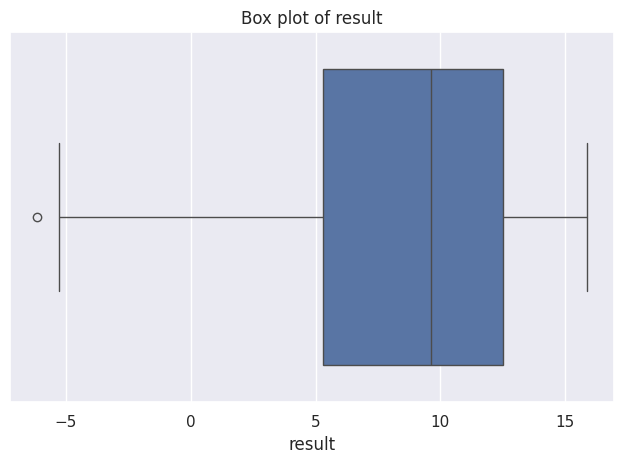

In [144]:
sns.boxplot(x=dataset['result'])
plt.title("Box plot of result")
plt.tight_layout()
plt.show()

In [145]:
#count the outliers using iqr method
q1=dataset['age'].quantile(0.25)
q3=dataset['age'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-(1.5*iqr)
upper_bound=q3+(1.5*iqr)
age_outliers=dataset[(dataset['age']<lower_bound) | (dataset['age']>upper_bound)]
print(f"Number of outliers in age: {len(age_outliers)}")

Number of outliers in age: 39


In [146]:
q1=dataset['result'].quantile(0.25)
q3=dataset['result'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-(1.5*iqr)
upper_bound=q3+(1.5*iqr)
result_outliers=dataset[(dataset['result']<lower_bound) | (dataset['result']>upper_bound)]
print(f"Number of outliers in result: {len(result_outliers)}")

Number of outliers in result: 1


univariate analysis of categorical feautres


In [147]:
dataset.columns

Index(['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender',
       'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before',
       'result', 'relation', 'Class/ASD'],
      dtype='object')

In [148]:
categorical_columns=['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'gender',
       'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before',
       'relation']

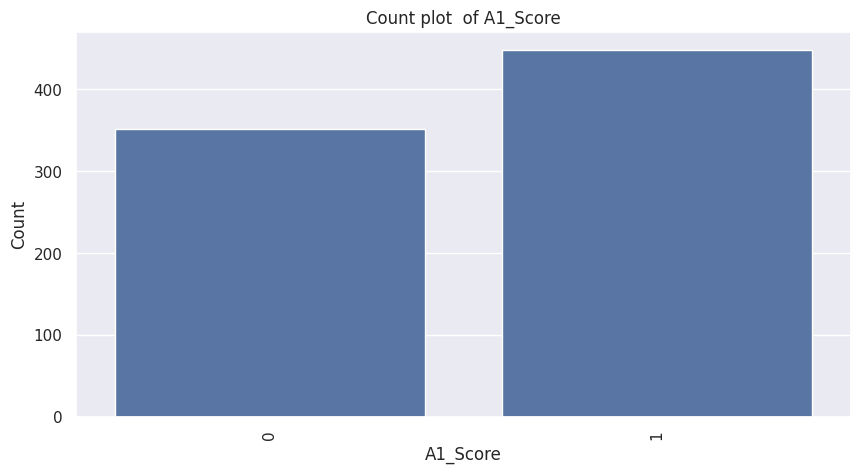

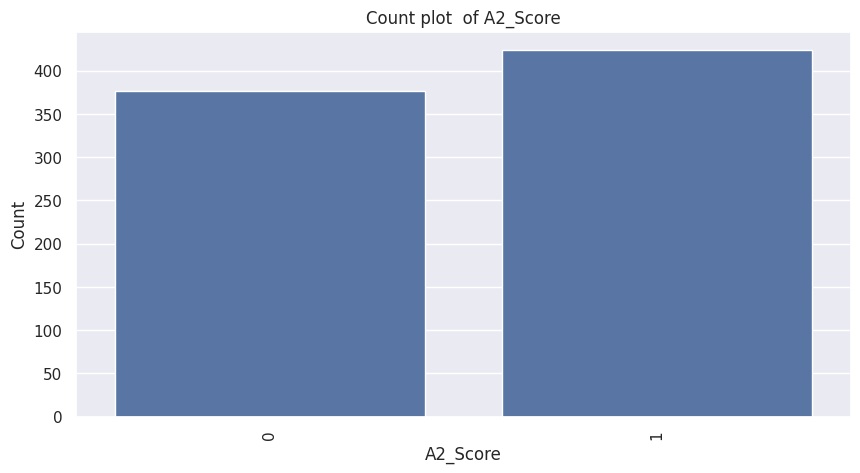

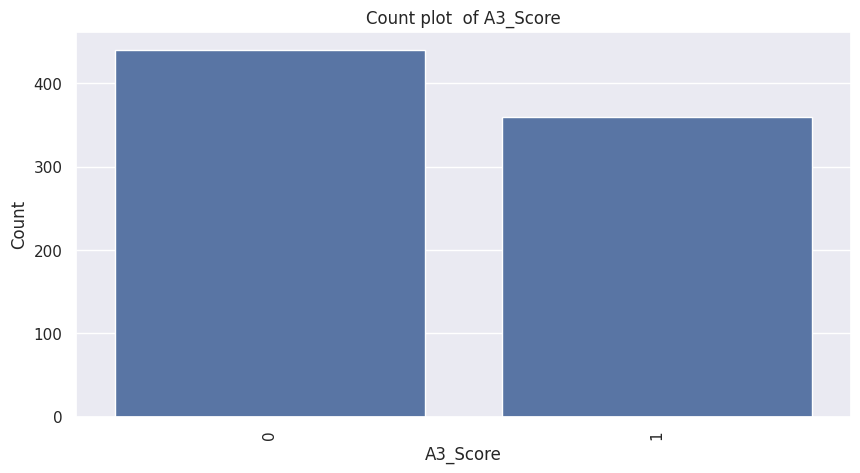

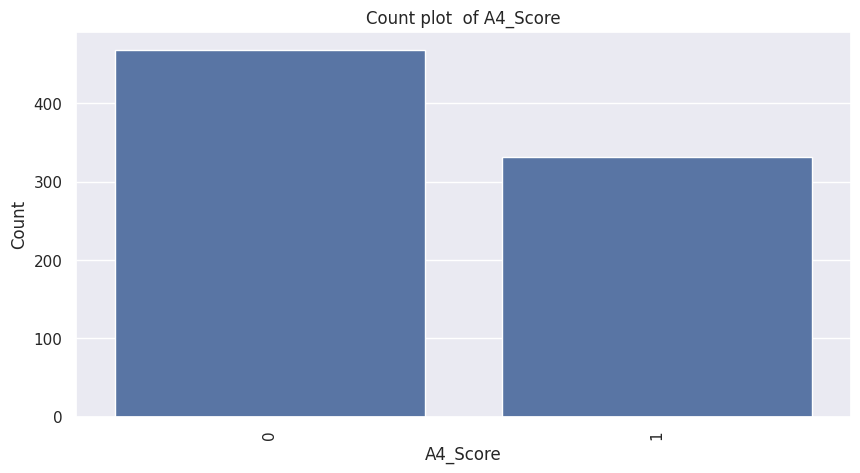

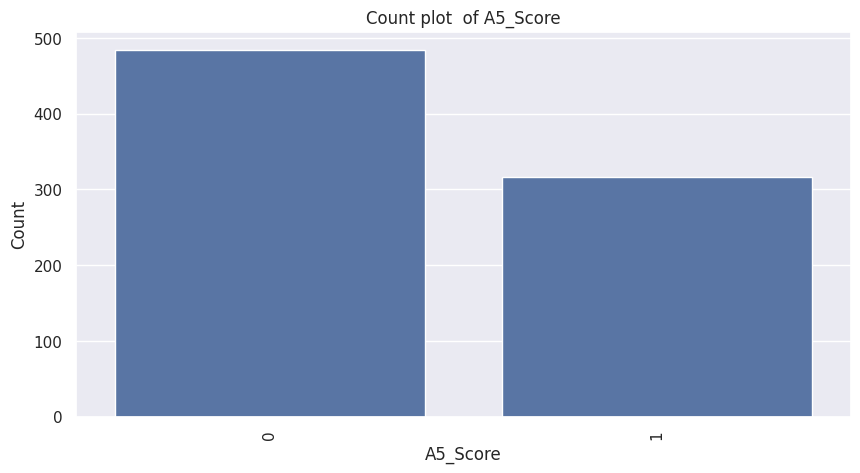

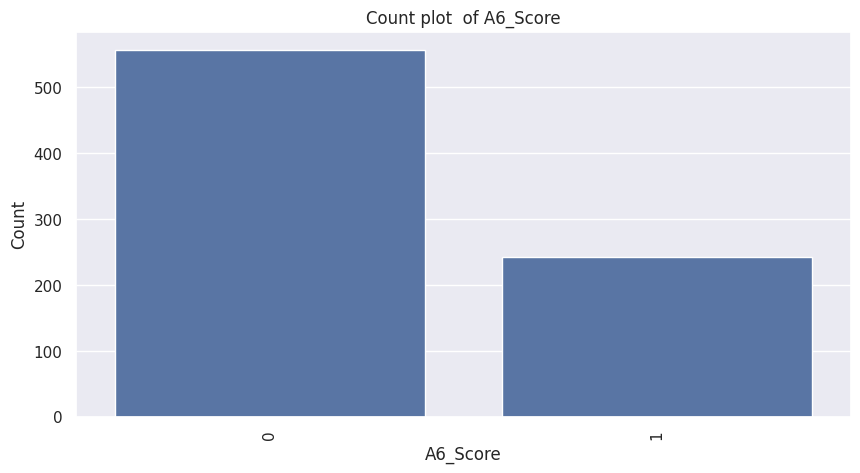

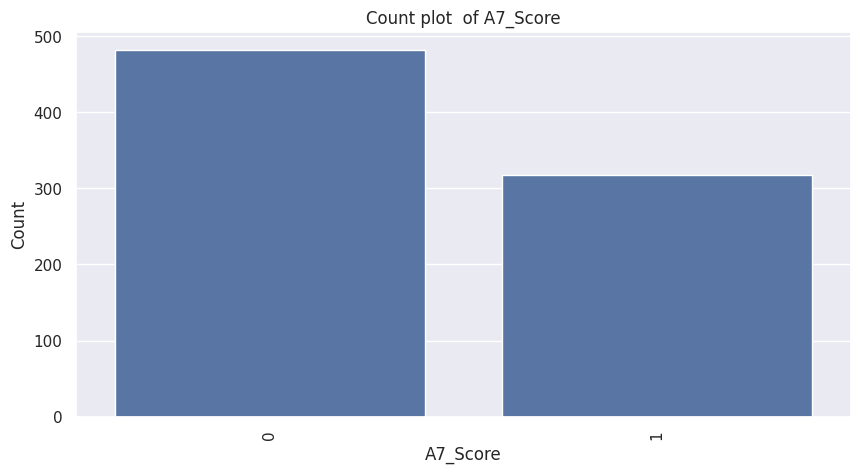

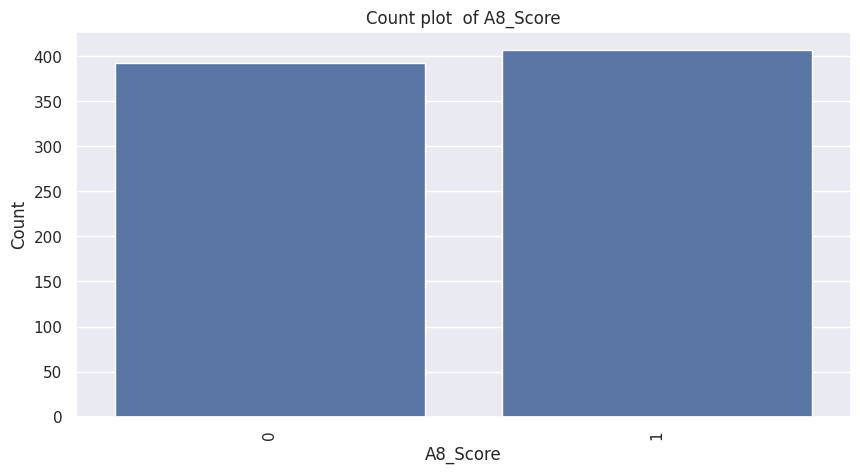

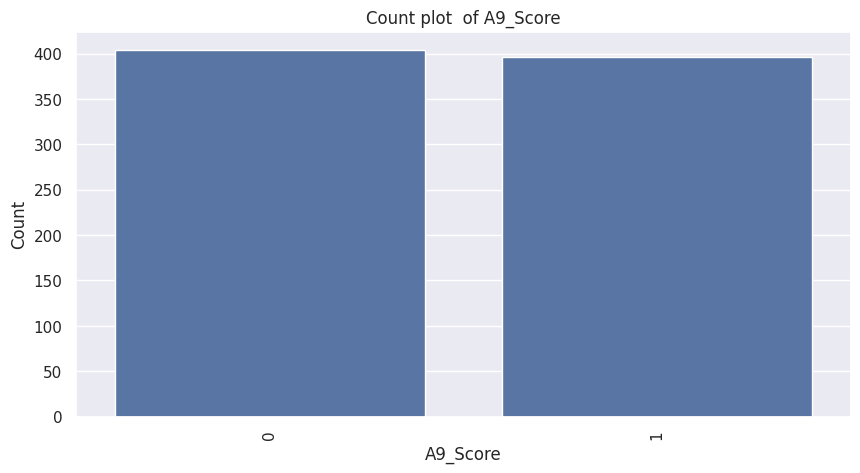

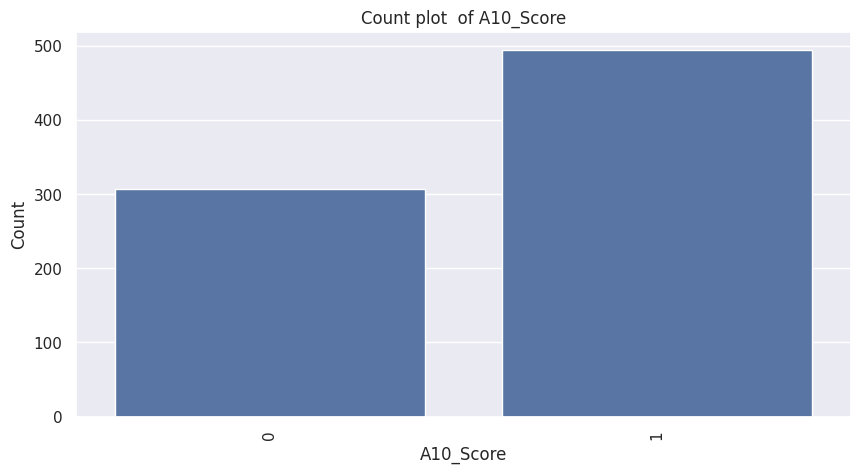

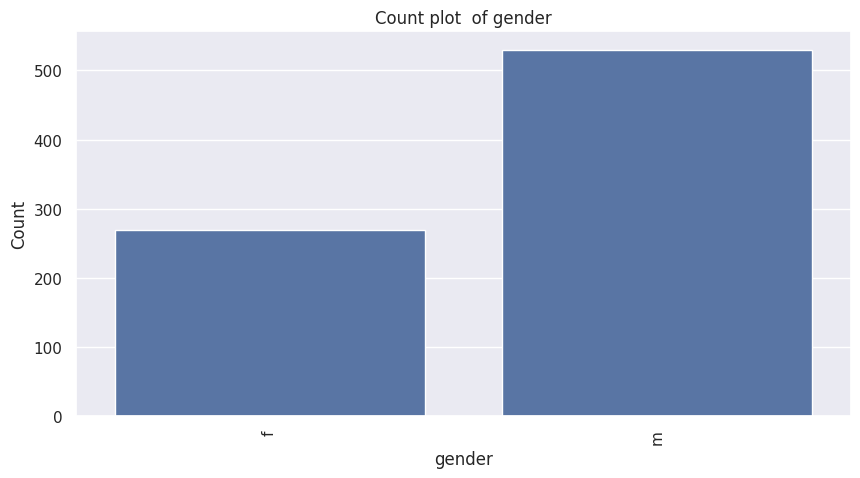

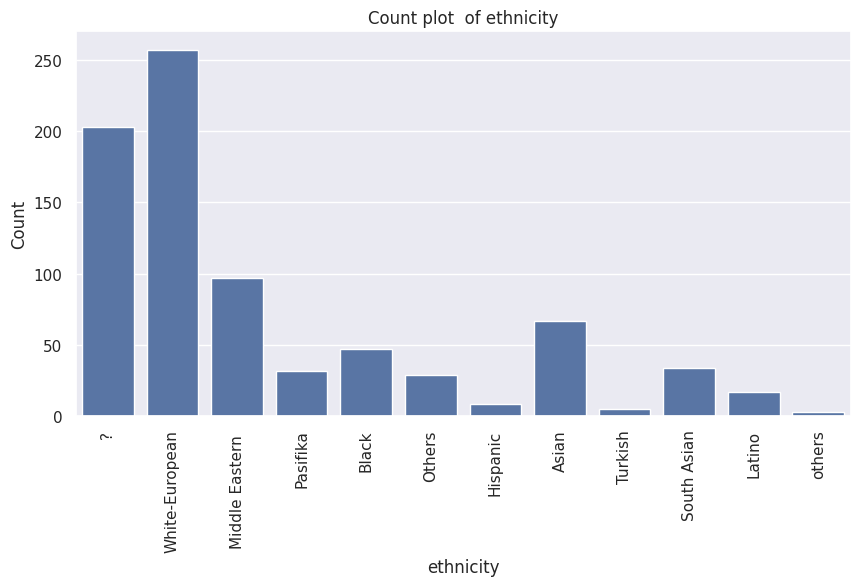

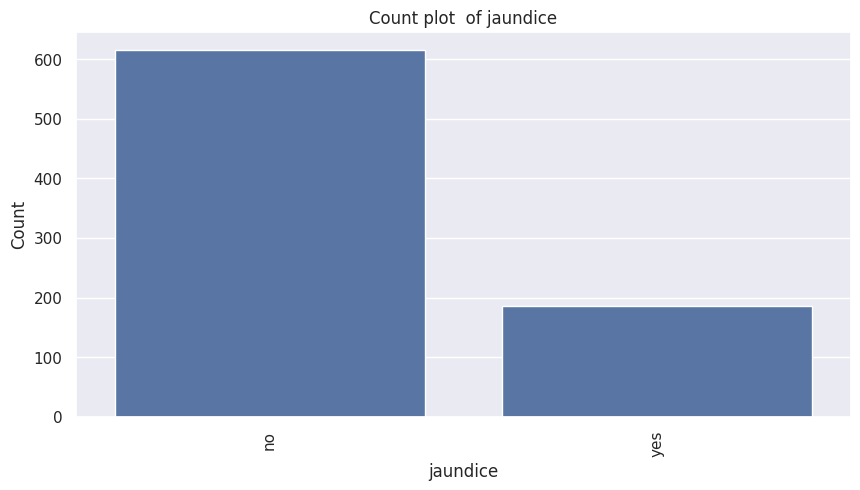

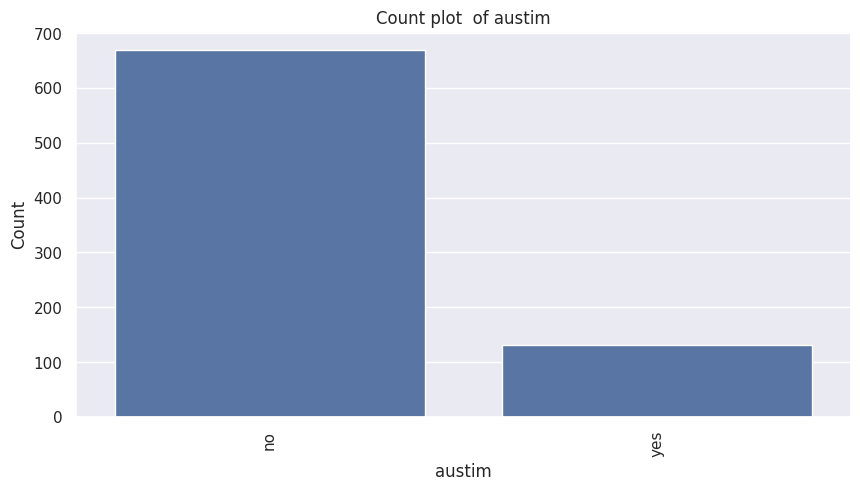

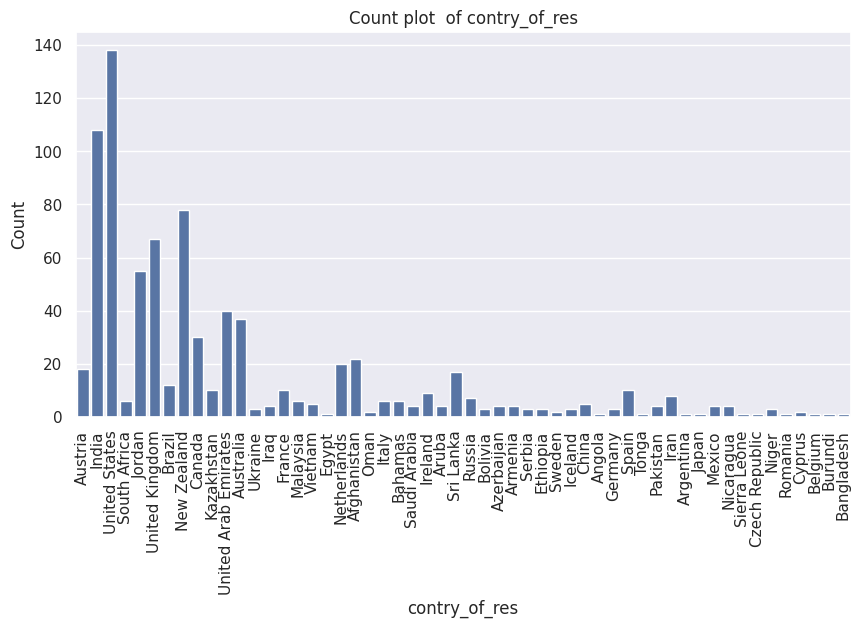

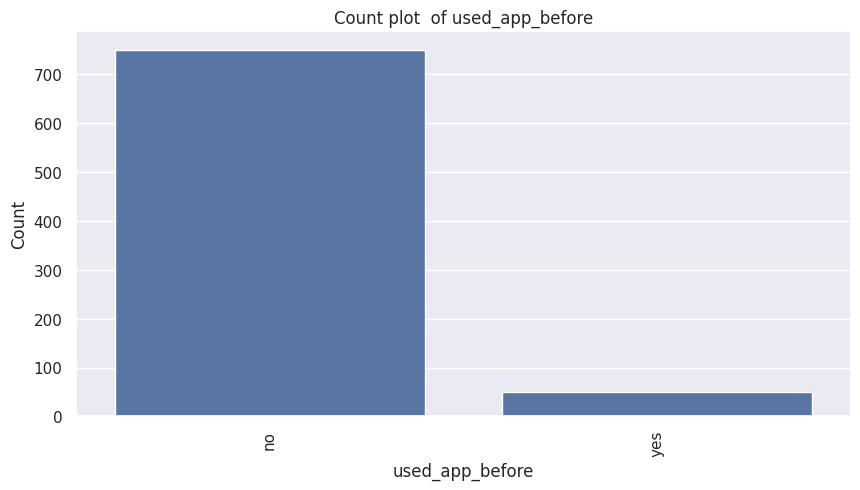

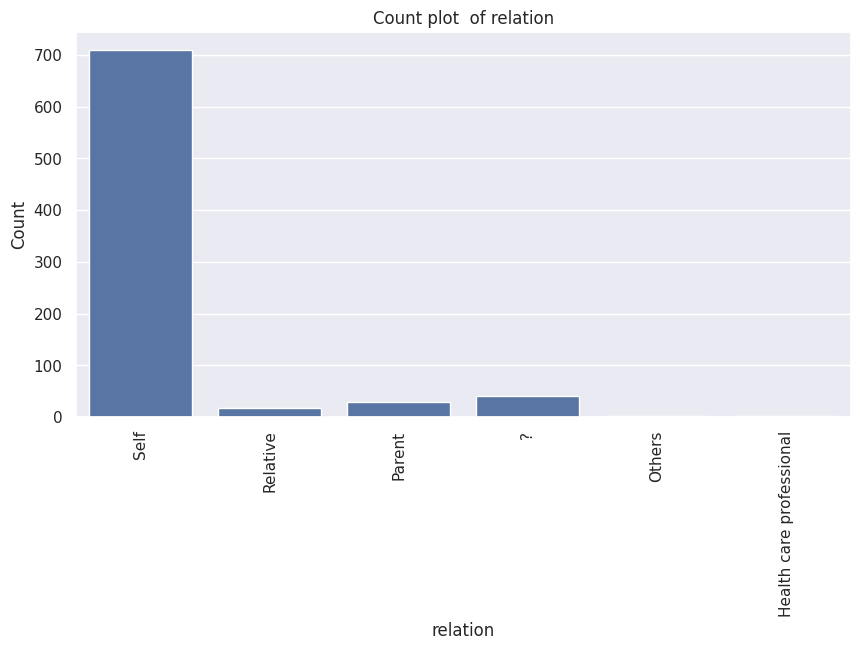

In [149]:
for column in categorical_columns:
    plt.figure(figsize=(10, 5))
    sns.countplot(x=dataset[column])
    plt.title(f"Count plot  of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.xticks(rotation=90)
    plt.show()

Text(0, 0.5, 'Count')

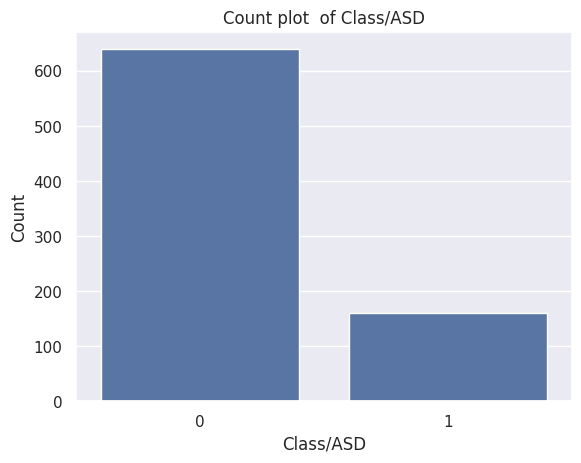

In [150]:
sns.countplot(x=dataset['Class/ASD'])
plt.title("Count plot  of Class/ASD")
plt.xlabel("Class/ASD")
plt.ylabel("Count")

In [151]:
dataset['Class/ASD'].value_counts()

,count
Class/ASD,
0,639
1,161


In [152]:
dataset['ethnicity'].value_counts()

,count
ethnicity,
White-European,257
?,203
Middle Eastern,97
Asian,67
Black,47
South Asian,34
Pasifika,32
Others,29
Latino,17


In [153]:
dataset['ethnicity']=dataset['ethnicity'].replace({"?":"Others","others":"Others"})

In [154]:
dataset['ethnicity'].value_counts()

,count
ethnicity,
White-European,257
Others,235
Middle Eastern,97
Asian,67
Black,47
South Asian,34
Pasifika,32
Latino,17
Hispanic,9


In [155]:
dataset['relation'].value_counts()

,count
relation,
Self,709
?,40
Parent,29
Relative,18
Others,2
Health care professional,2


In [156]:
dataset['relation']=dataset['relation'].replace({
    "?":"Others",
    "Parent":"Others",
    "Relative":"Others",
    "Health care professional":"Others"

})

In [157]:
dataset['relation'].value_counts()

,count
relation,
Self,709
Others,91


Label Encoding

In [158]:
object_column=dataset.select_dtypes(include='object').columns

In [159]:
encoders={}
for column in object_column:
    le=LabelEncoder()
    dataset[column]=le.fit_transform(dataset[column])
    encoders[column]=le


# save the encoders as a pickle file
with open("encoders.pkl", "wb") as f:
  pickle.dump(encoders, f)

In [160]:
encoders

{'gender': LabelEncoder(),
 'ethnicity': LabelEncoder(),
 'jaundice': LabelEncoder(),
 'austim': LabelEncoder(),
 'contry_of_res': LabelEncoder(),
 'used_app_before': LabelEncoder(),
 'relation': LabelEncoder()}

Bivariate Analyis

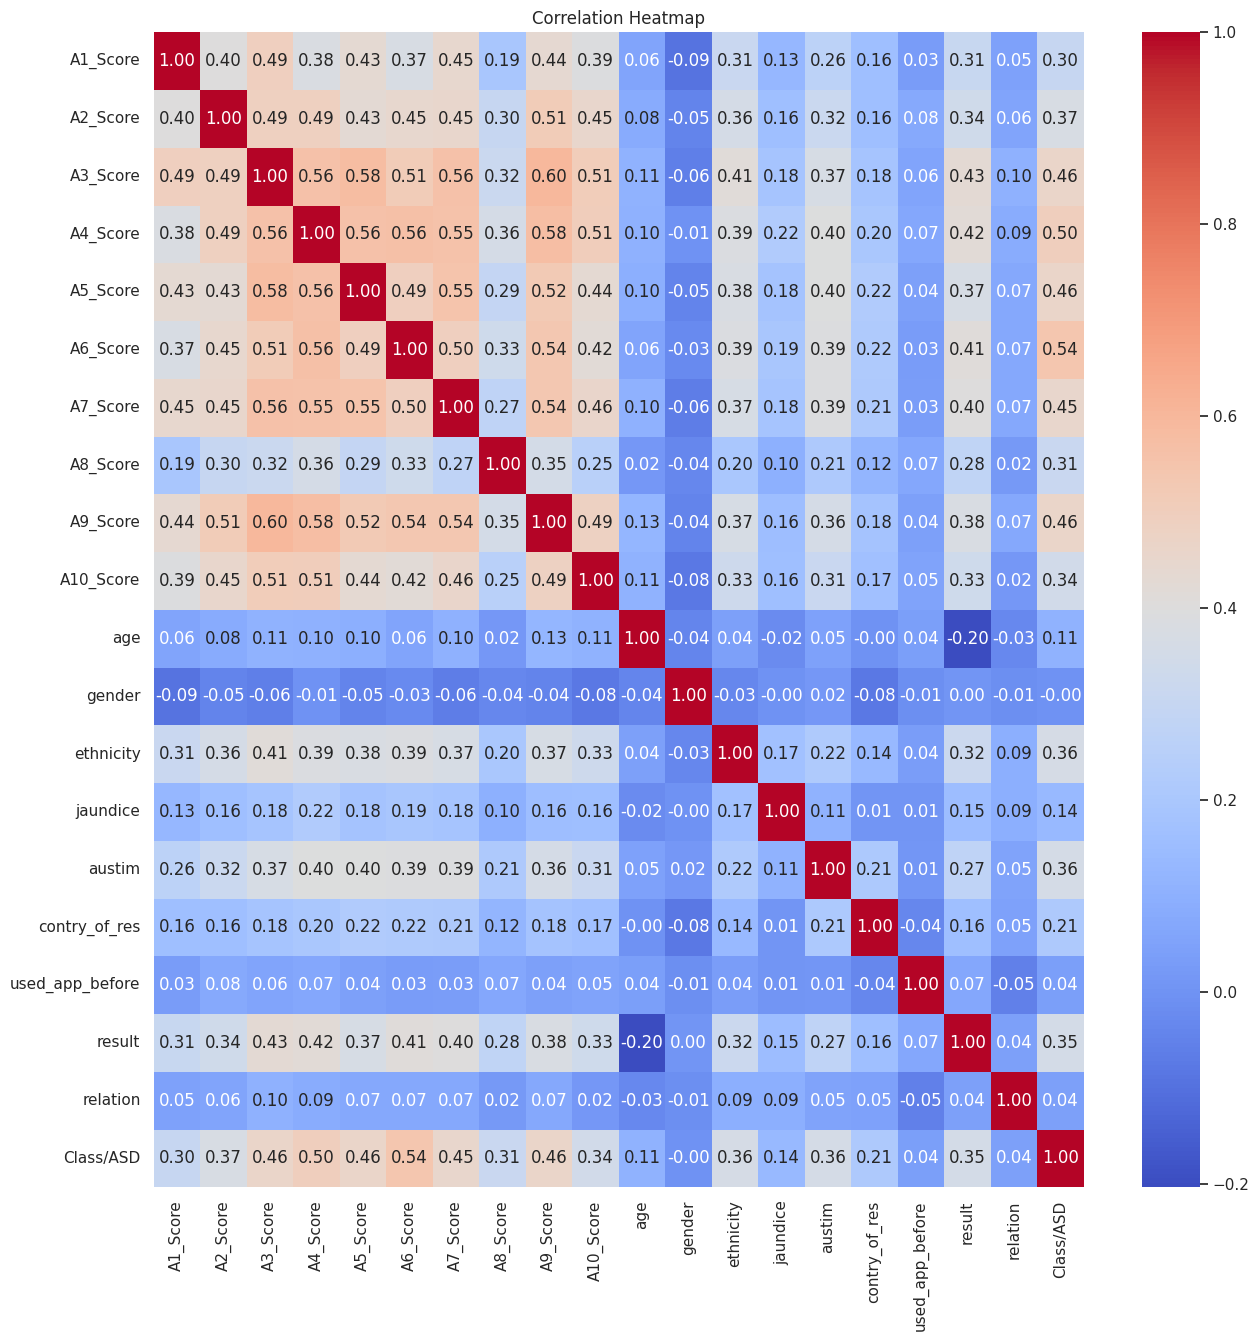

In [161]:
plt.figure(figsize=(15, 15))
sns.heatmap(dataset.corr(), annot=True, cmap='coolwarm',fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

data preprocessing

handling the outliers

In [167]:
def replace_outliers_with_median(dataset, column):
    q1 = dataset[column].quantile(0.25)
    q3 = dataset[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)
    median = dataset[column].median()
    # replace outliers with median value
    dataset[column] = dataset[column].apply(lambda x: median if x < lower_bound or x > upper_bound else x)

    return dataset


In [168]:
dataset=replace_outliers_with_median(dataset,"age")

In [169]:
dataset=replace_outliers_with_median(dataset,"result")

In [170]:
dataset.shape

(800, 20)

In [171]:
x=dataset.drop(columns=['Class/ASD'])
y=dataset['Class/ASD']

In [172]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [173]:
y_train.value_counts()

,count
Class/ASD,
0,515
1,125


In [174]:
y_test.value_counts()

,count
Class/ASD,
0,124
1,36


**SMOTE (Synthetic Minority Oversampling technique)**

In [175]:
smote=SMOTE()
x_train,y_train=smote.fit_resample(x_train,y_train)

In [176]:
y_train.value_counts()

,count
Class/ASD,
1,515
0,515


**Model Training**

In [178]:
models={
    "Decision Tree":DecisionTreeClassifier(),
    "Random Forest":RandomForestClassifier(),
    "XGBoost":XGBClassifier()
}


In [179]:
# dictionary to store the cross validation results
cv_scores = {}

for model_name,model in models.items():
    print(f"Training {model_name} with default parameters...")
    scores=cross_val_score(model,x_train,y_train,cv=5)
    cv_scores[model_name]=scores
    print(f"Cross validation scores for {model_name}: {scores}")
    print("-"*50)

Training Decision Tree with default parameters...
Cross validation scores for Decision Tree: [0.81553398 0.84951456 0.88349515 0.85436893 0.86893204]
--------------------------------------------------
Training Random Forest with default parameters...
Cross validation scores for Random Forest: [0.90291262 0.92718447 0.91262136 0.91747573 0.89320388]
--------------------------------------------------
Training XGBoost with default parameters...
Cross validation scores for XGBoost: [0.84951456 0.9223301  0.91262136 0.91747573 0.89805825]
--------------------------------------------------


**Model Selection & Hyperparameter Tuning**

In [180]:
# Initializing models
decision_tree = DecisionTreeClassifier(random_state=42)
random_forest = RandomForestClassifier(random_state=42)
xgboost_classifier = XGBClassifier(random_state=42)

In [181]:
# Hyperparameter grids for RandomizedSearchCV

param_grid_dectree={
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 10, 20, 30, 50, 70],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

param_grid_randmfort={
    "n_estimators": [50, 100, 200, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "bootstrap": [True, False]

}

param_grid_xgboost={
    "n_estimators": [50, 100, 200, 500],
    "max_depth": [3, 5, 7, 10],
    "learning_rate": [0.01, 0.1, 0.2, 0.3],
    "subsample": [0.5, 0.7, 1.0],
    "colsample_bytree": [0.5, 0.7, 1.0]
}

In [182]:
# hyperparameter tunig for 3 tree based models

# the below steps can be automated by using a for loop or by using a pipeline

# perform RandomizedSearchCV for each model
random_search_dectree = RandomizedSearchCV(estimator=decision_tree, param_distributions=param_grid_dectree, n_iter=20,cv=5, scoring="accuracy", random_state=42)
random_search_randmfort = RandomizedSearchCV(estimator=random_forest, param_distributions=param_grid_randmfort, n_iter=20,cv=5, scoring="accuracy", random_state=42)
random_search_xgboost = RandomizedSearchCV(estimator=xgboost_classifier, param_distributions=param_grid_xgboost, n_iter=20,cv=5, scoring="accuracy", random_state=42)



In [183]:
random_search_dectree.fit(x_train, y_train)
random_search_randmfort.fit(x_train, y_train)
random_search_xgboost.fit(x_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constrain...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=20,
                   param_distributions={'colsample_bytree': [0.5, 0.7, 1.0],
                                        'learning_rate': [0.01, 0.1, 0.2, 0.3],
                                        'max_depth': [3, 5, 7, 10],
                                        'n_estimators': [50, 100, 200, 500],
                                        'subsample': [0.5, 0.7, 1.0]},
                   random_state=42, scoring='accuracy')

In [184]:
# Get the model with best score
best_model=None
best_score=0

if random_search_dectree.best_score_>best_score:
    best_model=random_search_dectree.best_estimator_
    best_score=random_search_dectree.best_score_

if random_search_randmfort.best_score_>best_score:
    best_model=random_search_randmfort.best_estimator_
    best_score=random_search_randmfort.best_score_

if random_search_xgboost.best_score_>best_score:
    best_model=random_search_xgboost.best_estimator_
    best_score=random_search_xgboost.best_score_



In [185]:
print(f"Best Model: {best_model}")
print(f"Best Cross-Validation Accuracy: {best_score:.2f}")

Best Model: RandomForestClassifier(bootstrap=False, max_depth=20, n_estimators=50,
                       random_state=42)
Best Cross-Validation Accuracy: 0.92


In [186]:
# save the best model
with open("best_model.pkl", "wb") as f:
  pickle.dump(best_model, f)

**Evaluation**

In [187]:
y_test_pred=best_model.predict(x_test)
print("Accuracy score:\n", accuracy_score(y_test, y_test_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("Classification Report:\n", classification_report(y_test, y_test_pred))

Accuracy score:
 0.8
Confusion Matrix:
 [[109  15]
 [ 17  19]]
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.88      0.87       124
           1       0.56      0.53      0.54        36

    accuracy                           0.80       160
   macro avg       0.71      0.70      0.71       160
weighted avg       0.80      0.80      0.80       160



In [188]:
x_test.head(1)

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,relation
696,1,1,0,0,0,0,0,1,1,0,13.0,0,9,0,0,33,0,13.332323,1


In [190]:
#building a predictive system

input_data=(1,	1,	0,	0,	0,	0,	0,	1,	1,	0,	13.0,	0,	9,	0,	0,	33,	0,	13.332323,	1
)
input_data_as_numpy_array=np.asarray(input_data)
input_data_reshaped=np.reshape(input_data_as_numpy_array,(1,-1))
prediction=best_model.predict(input_data_reshaped)
print(prediction)

if prediction==0:
    print("The person does not have Autism")
else:
    print("The person has Autism")


[0]
The person does not have Autism


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
